In [1]:
import pandas as pd
import numpy as np
import requests
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
Top20genes = pd.read_csv("top20_genes_with_names.csv")

print("Shape:", Top20genes.shape)
display(Top20genes.head())
print("Columns:", Top20genes.columns.tolist())

Shape: (20, 6)


,probe_id,gene_name,correlation,p_value,abs_corr,gene_assignment
0,7961102,NM_001099431,0.613054,3.369721e-18,0.613054,NM_001099431 // CLEC1B // C-type lectin domain...
1,7958000,NM_020244,0.571658,1.589759e-15,0.571658,NM_020244 // CHPT1 // choline phosphotransfera...
2,8156706,NM_001166116,0.562609,5.457780e-15,0.562609,NM_001166116 // TMOD1 // tropomodulin 1 // 9q2...
3,8151592,NM_001128829,0.560207,7.525364e-15,0.560207,NM_001128829 // CA1 // carbonic anhydrase I //...
4,8095694,NM_002620,0.545923,4.822024e-14,0.545923,NM_002620 // PF4V1 // platelet factor 4 varian...


Columns: ['probe_id', 'gene_name', 'correlation', 'p_value', 'abs_corr', 'gene_assignment']


In [5]:
def extract_hgnc_symbol(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip()

    parts = [p.strip() for p in x.split("//")]

    if len(parts) >= 2:
        sym = parts[1].strip()
        if sym not in ["", "---", "NA", "nan", "None"]:
            return sym

    return np.nan

Top20genes["hgnc_symbol"] = Top20genes["gene_assignment"].apply(extract_hgnc_symbol)

display(Top20genes.head())

,probe_id,gene_name,correlation,p_value,abs_corr,gene_assignment,hgnc_symbol
0,7961102,NM_001099431,0.613054,3.369721e-18,0.613054,NM_001099431 // CLEC1B // C-type lectin domain...,CLEC1B
1,7958000,NM_020244,0.571658,1.589759e-15,0.571658,NM_020244 // CHPT1 // choline phosphotransfera...,CHPT1
2,8156706,NM_001166116,0.562609,5.457780e-15,0.562609,NM_001166116 // TMOD1 // tropomodulin 1 // 9q2...,TMOD1
3,8151592,NM_001128829,0.560207,7.525364e-15,0.560207,NM_001128829 // CA1 // carbonic anhydrase I //...,CA1
4,8095694,NM_002620,0.545923,4.822024e-14,0.545923,NM_002620 // PF4V1 // platelet factor 4 varian...,PF4V1


In [7]:
advisor_table = Top20genes[[
    "probe_id",
    "gene_name",        # RefSeq transcript ID
    "hgnc_symbol",      # extracted gene symbol
    "correlation",
    "p_value",
    "abs_corr",
    "gene_assignment"
]].copy()

advisor_table = advisor_table.sort_values("abs_corr", ascending=False).reset_index(drop=True)

display(advisor_table)
advisor_table.to_csv("top20_genes_advisor_ready.csv", index=False)
print("Saved: top20_genes_advisor_ready.csv")

,probe_id,gene_name,hgnc_symbol,correlation,p_value,abs_corr,gene_assignment
0,7961102,NM_001099431,CLEC1B,0.613054,3.369721e-18,0.613054,NM_001099431 // CLEC1B // C-type lectin domain...
1,7958000,NM_020244,CHPT1,0.571658,1.589759e-15,0.571658,NM_020244 // CHPT1 // choline phosphotransfera...
2,8156706,NM_001166116,TMOD1,0.562609,5.457780e-15,0.562609,NM_001166116 // TMOD1 // tropomodulin 1 // 9q2...
3,8151592,NM_001128829,CA1,0.560207,7.525364e-15,0.560207,NM_001128829 // CA1 // carbonic anhydrase I //...
4,8095694,NM_002620,PF4V1,0.545923,4.822024e-14,0.545923,NM_002620 // PF4V1 // platelet factor 4 varian...
5,8173135,NM_000032,ALAS2,0.536789,1.511288e-13,0.536789,"NM_000032 // ALAS2 // aminolevulinate, delta-,..."
6,8131067,NM_138445,GPR146,0.531220,2.982385e-13,0.531220,NM_138445 // GPR146 // G protein-coupled recep...
7,8180346,NaN,NaN,0.527916,4.437942e-13,0.527916,---
8,8063478,NM_080821,FAM210B,0.524336,6.794352e-13,0.524336,NM_080821 // FAM210B // family with sequence s...
9,7953901,NM_001207010,CLEC12A,0.521666,9.304555e-13,0.521666,NM_001207010 // CLEC12A // C-type lectin domai...


Saved: top20_genes_advisor_ready.csv


In [9]:
genes_for_network = (
    advisor_table["hgnc_symbol"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

print("Genes for network:", genes_for_network)
print("Number of genes:", len(genes_for_network))

Genes for network: ['CLEC1B', 'CHPT1', 'TMOD1', 'CA1', 'PF4V1', 'ALAS2', 'GPR146', 'FAM210B', 'CLEC12A', 'JAZF1', 'SNX3', 'NBR2', 'IGF2BP2', 'MXI1', 'TCP11L2', 'DENND4A', 'TRAK2', 'FAM104A']
Number of genes: 18


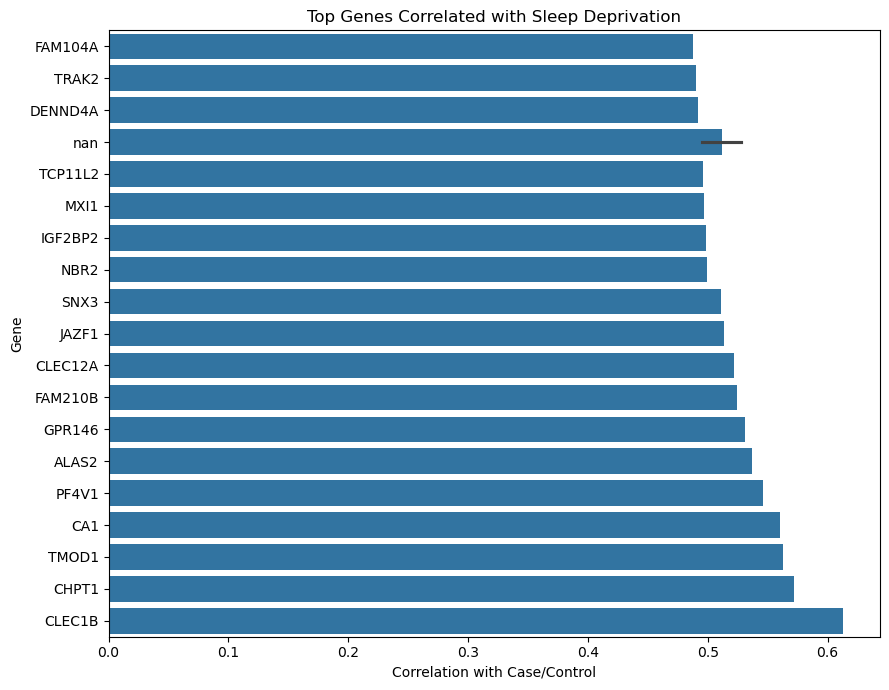

In [11]:
plot_df = advisor_table.copy()
plot_df["label"] = plot_df["hgnc_symbol"].fillna(plot_df["gene_name"]).astype(str)
plot_df = plot_df.sort_values("correlation")

plt.figure(figsize=(9, 7))
sns.barplot(data=plot_df, x="correlation", y="label")
plt.title("Top Genes Correlated with Sleep Deprivation")
plt.xlabel("Correlation with Case/Control")
plt.ylabel("Gene")
plt.tight_layout()
plt.show()

In [13]:
species = 9606  # human
identifiers = "%0d".join(genes_for_network)

string_api_url = "https://string-db.org/api"
output_format = "tsv-no-header"
method = "network"

request_url = "/".join([string_api_url, output_format, method])

params = {
    "identifiers": identifiers,
    "species": species,
    "required_score": 400,   # medium confidence
    "network_flavor": "confidence",
    "caller_identity": "sleep_deprivation_project"
}

response = requests.post(request_url, data=params)

print("Status code:", response.status_code)
print(response.text[:500])

Status code: 200
9606.ENSP00000226524	9606.ENSP00000298527	PF4V1	CLEC1B	9606	0.55	0	0	0	0.263	0	0	0.414
9606.ENSP00000259365	9606.ENSP00000497236	TMOD1	ALAS2	9606	0.408	0	0	0	0.248	0	0	0.245
9606.ENSP00000283928	9606.ENSP00000410242	JAZF1	IGF2BP2	9606	0.674	0	0	0	0.06	0	0	0.668
9606.ENSP00000298527	9606.ENSP00000347916	CLEC1B	CLEC12A	9606	0.56	0	0	0	0.426	0	0	0.265
9606.ENSP00000360437	9606.ENSP00000497236	FAM210B	ALAS2	9606	0.417	0	0	0	0.115	0	0	0.368
9606.ENSP00000430656	9606.ENSP00000497236	CA1	ALAS2	9606	0.8


In [15]:
lines = response.text.strip().split("\n")
data = [line.strip().split("\t") for line in lines if line.strip()]

string_df = pd.DataFrame(data, columns=[
    "stringId_A","stringId_B","preferredName_A","preferredName_B",
    "ncbiTaxonId","score","nscore","fscore","pscore","ascore",
    "escore","dscore","tscore"
])

string_df["score"] = pd.to_numeric(string_df["score"], errors="coerce")

print("Interactions found:", string_df.shape[0])
display(string_df.head())

Interactions found: 6


,stringId_A,stringId_B,preferredName_A,preferredName_B,ncbiTaxonId,score,nscore,fscore,pscore,ascore,escore,dscore,tscore
0,9606.ENSP00000226524,9606.ENSP00000298527,PF4V1,CLEC1B,9606,0.550,0,0,0,0.263,0,0,0.414
1,9606.ENSP00000259365,9606.ENSP00000497236,TMOD1,ALAS2,9606,0.408,0,0,0,0.248,0,0,0.245
2,9606.ENSP00000283928,9606.ENSP00000410242,JAZF1,IGF2BP2,9606,0.674,0,0,0,0.06,0,0,0.668
3,9606.ENSP00000298527,9606.ENSP00000347916,CLEC1B,CLEC12A,9606,0.560,0,0,0,0.426,0,0,0.265
4,9606.ENSP00000360437,9606.ENSP00000497236,FAM210B,ALAS2,9606,0.417,0,0,0,0.115,0,0,0.368


In [17]:
G = nx.Graph()

for _, row in string_df.iterrows():
    gene_a = row["preferredName_A"]
    gene_b = row["preferredName_B"]
    score = row["score"]

    G.add_edge(gene_a, gene_b, weight=score)

print("Number of proteins (nodes):", G.number_of_nodes())
print("Number of interactions (edges):", G.number_of_edges())

Number of proteins (nodes): 9
Number of interactions (edges): 6


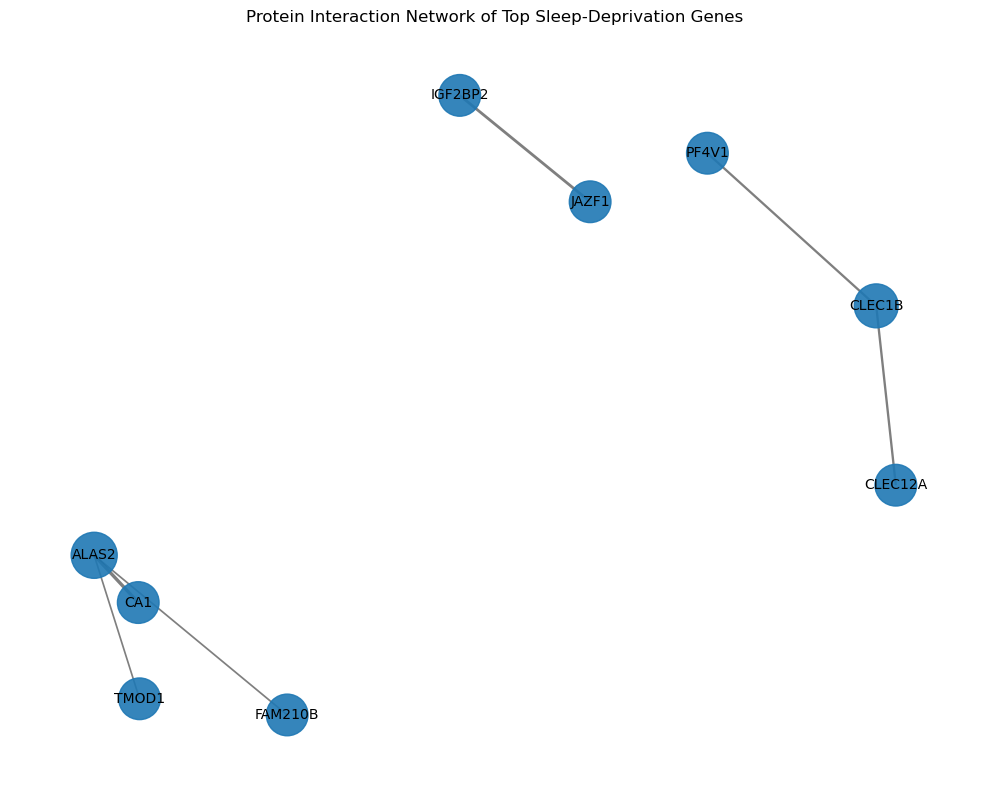

In [19]:
plt.figure(figsize=(10, 8))

pos = nx.spring_layout(G, seed=42, k=0.7)

edge_weights = [G[u][v]["weight"] for u, v in G.edges()]
node_sizes = [800 + 100 * G.degree(n) for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_edges(G, pos, width=[w * 3 for w in edge_weights], alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=10)

plt.title("Protein Interaction Network of Top Sleep-Deprivation Genes")
plt.axis("off")
plt.tight_layout()
plt.show()

In [21]:
degree_df = pd.DataFrame({
    "gene": list(dict(G.degree()).keys()),
    "degree": list(dict(G.degree()).values())
}).sort_values("degree", ascending=False)

display(degree_df.head(10))
degree_df.to_csv("protein_interaction_network_hubs.csv", index=False)
print("Saved: protein_interaction_network_hubs.csv")

,gene,degree
3,ALAS2,3
1,CLEC1B,2
0,PF4V1,1
2,TMOD1,1
4,JAZF1,1
5,IGF2BP2,1
6,CLEC12A,1
7,FAM210B,1
8,CA1,1


Saved: protein_interaction_network_hubs.csv


In [23]:
edge_list = nx.to_pandas_edgelist(G)
edge_list.to_csv("protein_interaction_network_edges.csv", index=False)

print("Saved: protein_interaction_network_edges.csv")

Saved: protein_interaction_network_edges.csv
